<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da06_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA(Exploratory Data Analysis, 탐색적 데이터 분석)

시각화와 통계적인 방법으로 자료를 분석하는 과정.

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# iris 데이터셋

In [2]:
iris = sns.load_dataset(name='iris')

In [3]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
iris.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [5]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
iris.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [7]:
iris.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [8]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


![iris](https://media2.dev.to/dynamic/image/width=1000,height=420,fit=cover,gravity=auto,format=auto/https%3A%2F%2Fdev-to-uploads.s3.amazonaws.com%2Fuploads%2Farticles%2F2tcrzxvzwfn64ru9jb5p.png)


*   숫자 타입 변수들의 box plot
*   숫자 타입 변수들의 평균 막대 그래프
*   품종별 모든 연속형 변수들의 box plot
*   품종별 모든 연속형 변수들의 평균 막대 그래프
*   petal_length ~ petal_width 산점도, 품종별로 색깔을 다르게 시각화.
*   sepal_length ~ sepal_width 산점도, 품종별로 색깔을 다르게 시각화.
*   모든 연속형 변수들 간의 상관관계(산점도). 힌트: `seaborn.pairplot()`


## Box plot

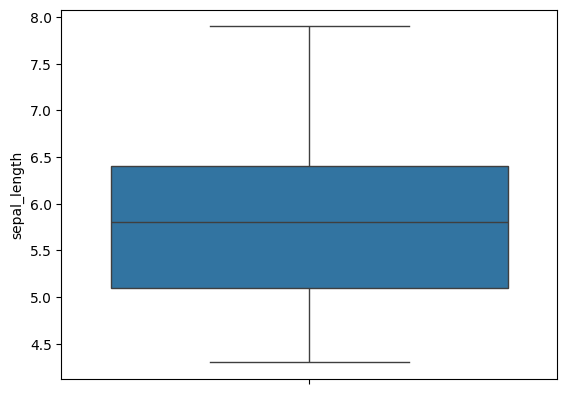

In [9]:
sns.boxplot(data=iris, y='sepal_length')
plt.show()

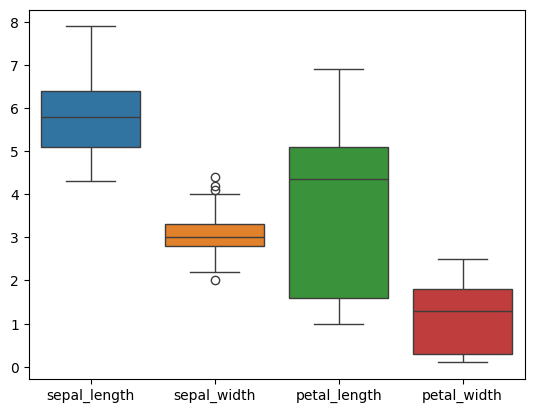

In [10]:
sns.boxplot(data=iris)
plt.show()

## 품종별 box plot

In [11]:
species = iris.species.unique()
species

array(['setosa', 'versicolor', 'virginica'], dtype=object)

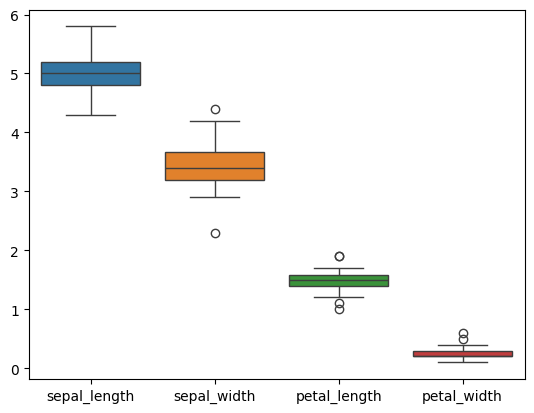

In [12]:
# setosa의 4개 연속형 변수 box plot
setosa_df = iris[iris.species == 'setosa']
sns.boxplot(data=setosa_df)
plt.show()

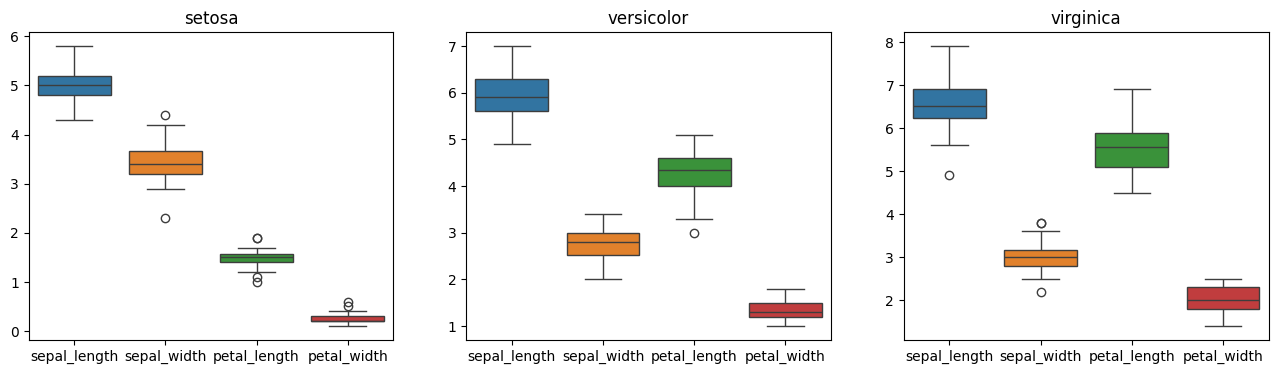

In [13]:
fig, axes = plt.subplots(ncols=3, figsize=(16, 4))

for i, s in enumerate(species):
    subset_df = iris[iris.species == s]
    sns.boxplot(data=subset_df, ax=axes[i])
    axes[i].set_title(s)

plt.show()

## 막대 그래프

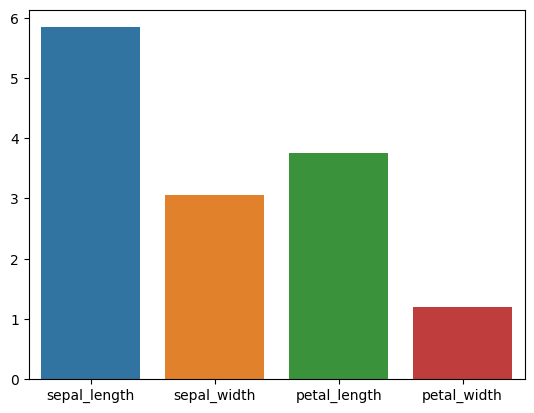

In [14]:
sns.barplot(data=iris, errorbar=None)
plt.show()

## 품종별 평균 막대 그래프

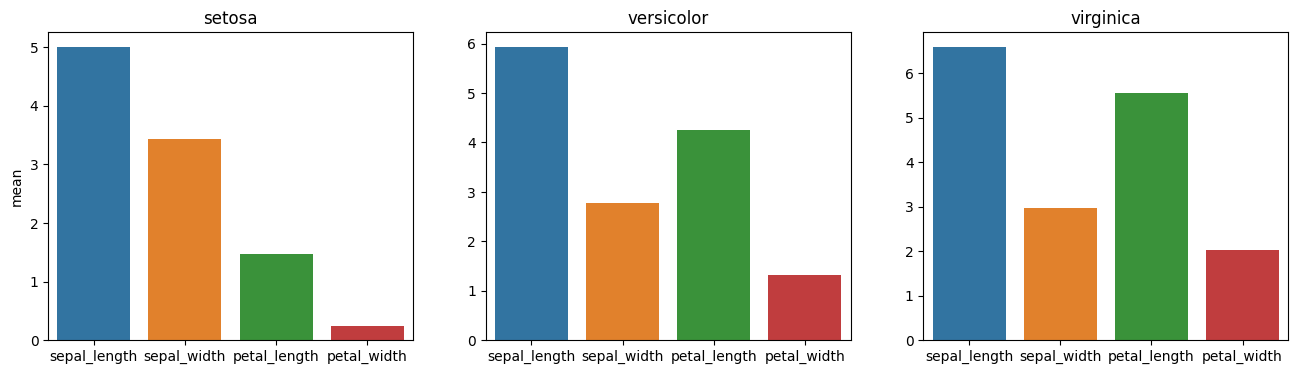

In [15]:
fig, axes = plt.subplots(ncols=3, figsize=(16, 4))

for i, s in enumerate(species):
    subset_df = iris[iris.species == s]
    sns.barplot(data=subset_df, ax=axes[i], errorbar=None)
    axes[i].set_title(s)
axes[0].set_ylabel('mean')

plt.show()

## 산점도

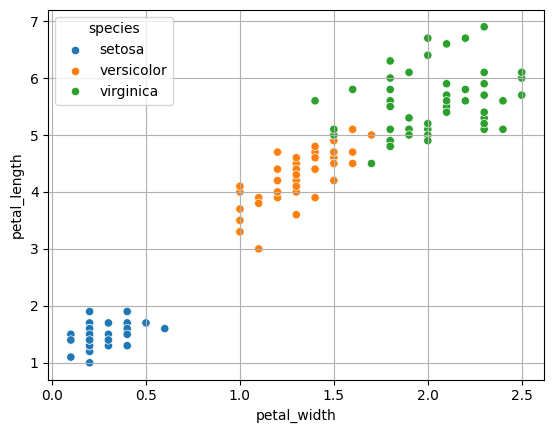

In [16]:
# petal_length ~ petal_width 산점도
sns.scatterplot(data=iris, x='petal_width', y='petal_length', hue='species')
plt.grid()
plt.show()

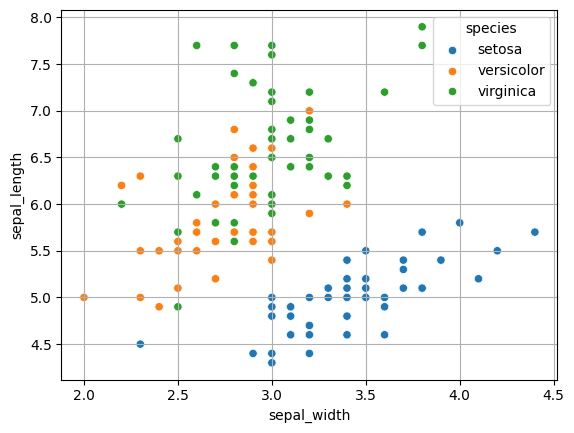

In [17]:
# sepal_length ~ sepal_width 산점도
sns.scatterplot(data=iris, x='sepal_width', y='sepal_length', hue='species')
plt.grid()
plt.show()

## 연속형 변수들 간의 상관 관계

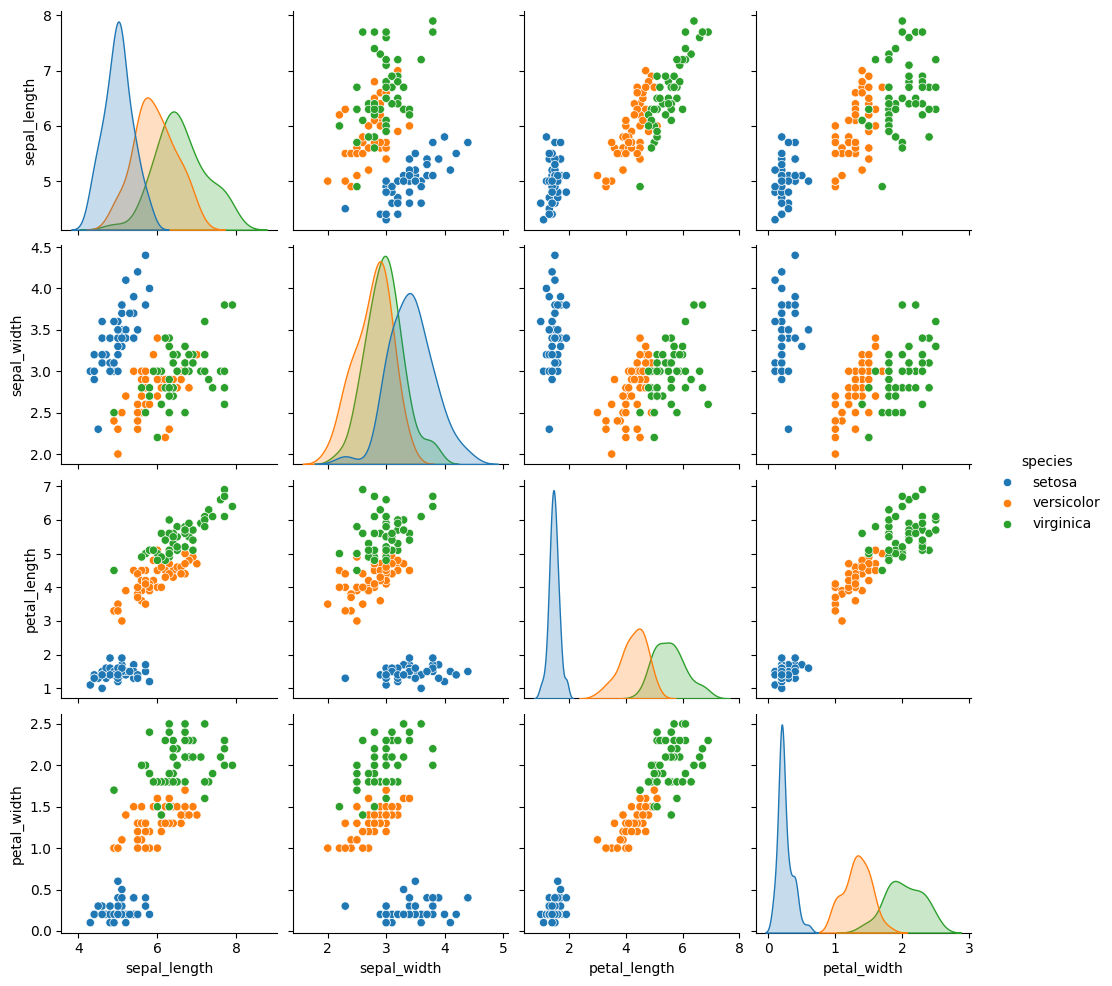

In [18]:
sns.pairplot(data=iris, hue='species')
plt.show()

In [19]:
df = iris[['petal_length', 'petal_width', 'species']]
df.head()

,petal_length,petal_width,species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


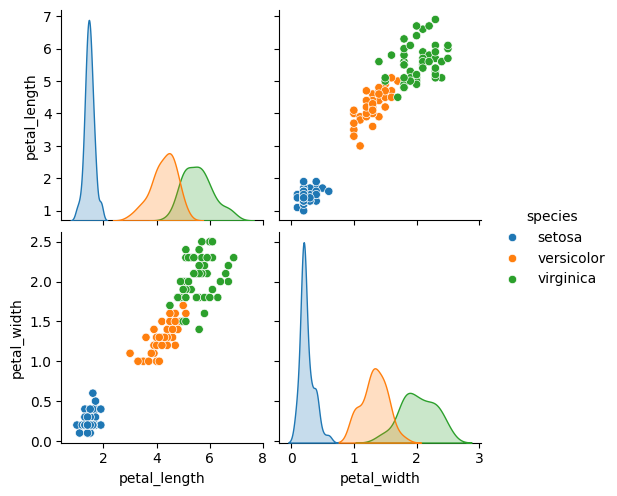

In [20]:
sns.pairplot(data=df, hue='species')
plt.show()

# mpg 데이터셋

In [21]:
mpg = sns.load_dataset(name='mpg')

In [22]:
mpg.head(n=10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [23]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


mpg(mile per gallon, 자동차 연비) 데이터프레임

*   mpg: 자동차 연비(mile/gallon)
*   cylinders: 자동차 실린더 개수
*   displacement: 배기량.
*   horsepower: 마력.
*   weight: 무게.
*   acceleration: 가속도.
*   model_year: 생산 연도.
*   origin: 생산 지역.
*   name: 자동차 이름.


Exercises

*   카테고리 타입 빈도수
*   산점도
    *   mpg(연비) ~ displacement(배기량)
    *   2x2 모양의 subplot을 생성
        *   mpg ~ cylinders(실린더 개수)
        *   mpg ~ horsepower(마력)
        *   mpg ~ weight(무게)
        *   mpg ~ acceleration(가속도)
*   빈도수 막대 그래프
    *   cyliners 빈도수
    *   origin(자동차 생산 지역) 빈도수
    *   model_year(자동차 생산 연도) 빈도수
        *   선 그래프 가능?
    *   origin 별, cylinders 별 빈도수
*   통계량 막대 그래프 - 2개의 subplot 생성
    *   cylinders 별 mpg의 중앙값(median)
    *   origin 별 mpg의 중앙값

*   Box plot
    *   3개의 subplot을 생성
        *   mpg, displacement, weight box plot
    *   origin 별 mpg box plot
*   Histogram
    *   4개의 subplot을 생성
        *   mpg, displacement, weight, model_year histogram
*   Pair plot


## 산점도

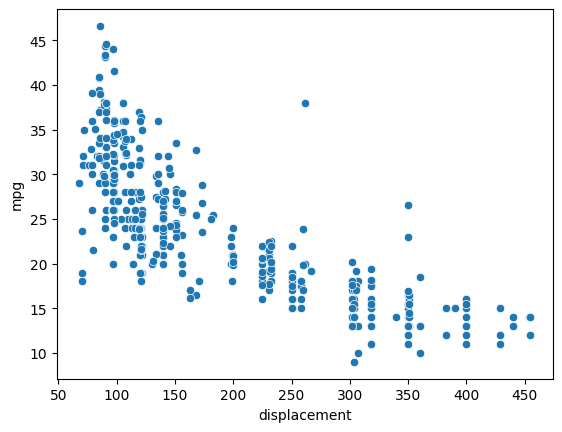

In [24]:
# mpg(연비) ~ displacement(배기량)
sns.scatterplot(data=mpg, x='displacement', y='mpg')
plt.show()

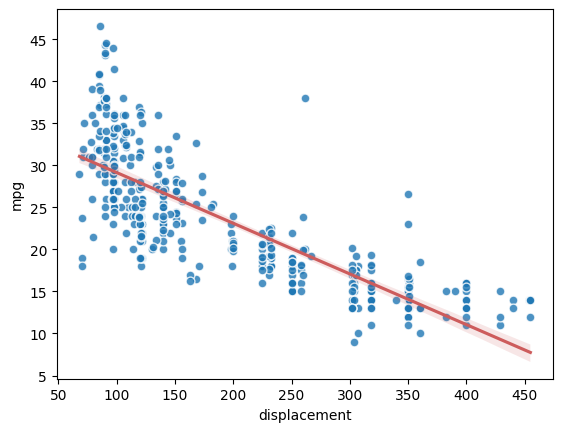

In [25]:
sns.regplot(data=mpg, x='displacement', y='mpg',
            scatter_kws={'s': 40, 'edgecolor': 'white'},
            line_kws={'color': 'IndianRed'})
plt.show()

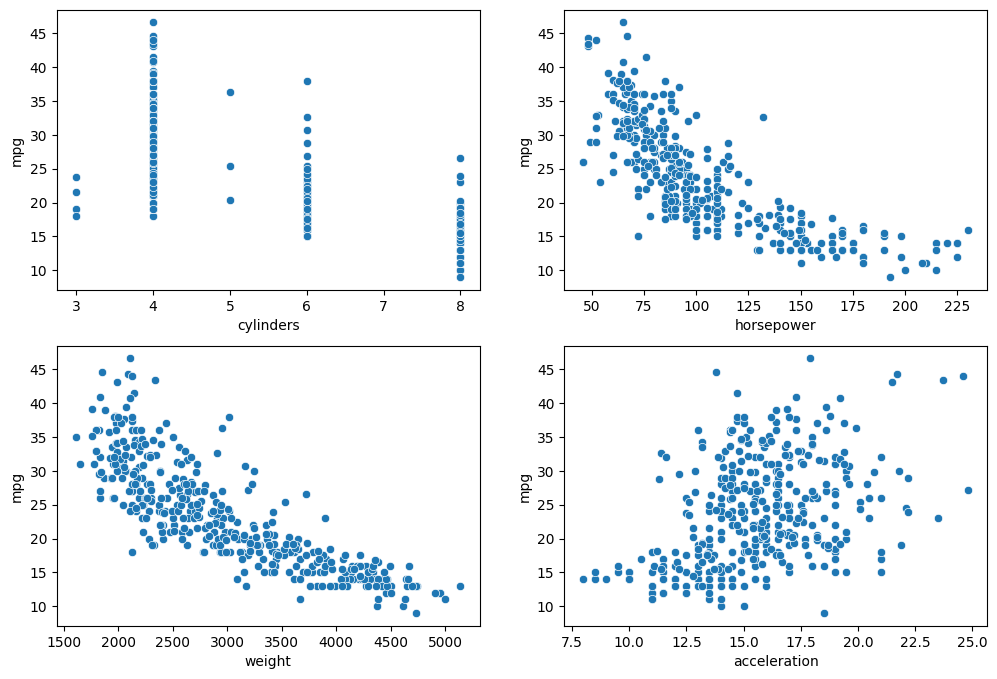

In [26]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# sns.scatterplot(data=mpg, y='mpg', x='cylinders', ax=axes[0, 0])
# sns.scatterplot(data=mpg, y='mpg', x='horsepower', ax=axes[0, 1])
# sns.scatterplot(data=mpg, y='mpg', x='weight', ax=axes[1, 0])
# sns.scatterplot(data=mpg, y='mpg', x='acceleration', ax=axes[1, 1])

vars = [['cylinders', 'horsepower'],
        ['weight', 'acceleration']]
# print(mpg.columns[[1, 3, 4, 5]])
# print(np.reshape(mpg.columns[[1, 3, 4, 5]], (2, 2)))

for i, row in enumerate(vars):
    for j, v in enumerate(row):
        sns.scatterplot(data=mpg, y='mpg', x=v, ax=axes[i, j])

plt.show()

**상관계수(correlation coefficients)**

*   두 변수 간의 상관 관계를 수치로 표현한 값.
*   종류: Pearson, Spearman, Kendall
*   -1 ~ +1 사이의 값을 갖음.
*   상관계수가 $\pm 1$에 가까울 수록 상관관계가 크다고 말함.
*   상관계수가 0에 가까울 수록 상관관계가 작다고 말함.

In [27]:
mpg[mpg.columns[:6]].corr(method='pearson')  # Pearson 상관계수

,mpg,cylinders,displacement,horsepower,weight,acceleration
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000


In [28]:
mpg[mpg.columns[:6]].corr(method='spearman')

,mpg,cylinders,displacement,horsepower,weight,acceleration
mpg,1.000000,-0.821864,-0.855692,-0.853616,-0.874947,0.438677
cylinders,-0.821864,1.000000,0.911876,0.816188,0.873314,-0.474189
displacement,-0.855692,0.911876,1.000000,0.876171,0.945986,-0.496512
horsepower,-0.853616,0.816188,0.876171,1.000000,0.878819,-0.658142
weight,-0.874947,0.873314,0.945986,0.878819,1.000000,-0.404550
acceleration,0.438677,-0.474189,-0.496512,-0.658142,-0.404550,1.000000


In [29]:
mpg[mpg.columns[:6]].corr(method='kendall')

,mpg,cylinders,displacement,horsepower,weight,acceleration
mpg,1.000000,-0.686477,-0.679847,-0.679166,-0.694006,0.301096
cylinders,-0.686477,1.000000,0.794854,0.686146,0.735481,-0.367194
displacement,-0.679847,0.794854,1.000000,0.718471,0.800508,-0.352110
horsepower,-0.679166,0.686146,0.718471,1.000000,0.703730,-0.488239
weight,-0.694006,0.735481,0.800508,0.703730,1.000000,-0.268619
acceleration,0.301096,-0.367194,-0.352110,-0.488239,-0.268619,1.000000


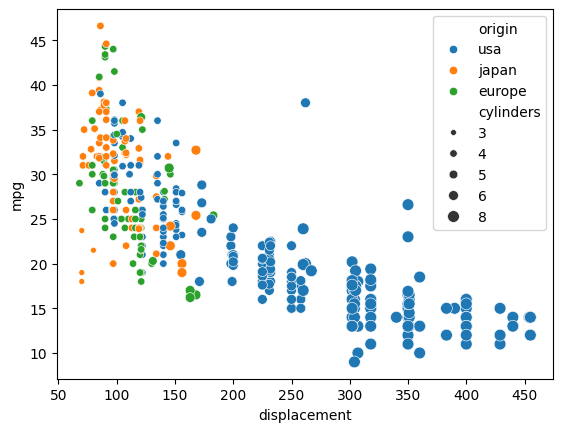

In [30]:
# 지역(origin), 실린더 개수(cylinders)를 mpg ~ displacement 산점도에 함께 시각화.
sns.scatterplot(data=mpg, x='displacement', y='mpg',
                hue='origin', size='cylinders')
plt.show()

In [31]:
figure = px.scatter(data_frame=mpg, x='displacement', y='mpg',
                    color='origin', size='cylinders',
                    width=800, height=600, size_max=12)
figure.show()

## 빈도수 막대 그래프

In [32]:
mpg.cylinders.value_counts()

,count
cylinders,
4,204
8,103
6,84
3,4
5,3


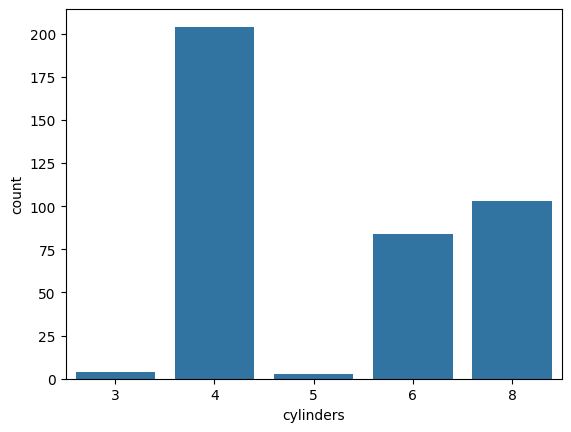

In [33]:
sns.countplot(data=mpg, x='cylinders')
plt.show()

In [34]:
mpg.origin.value_counts()

,count
origin,
usa,249
japan,79
europe,70


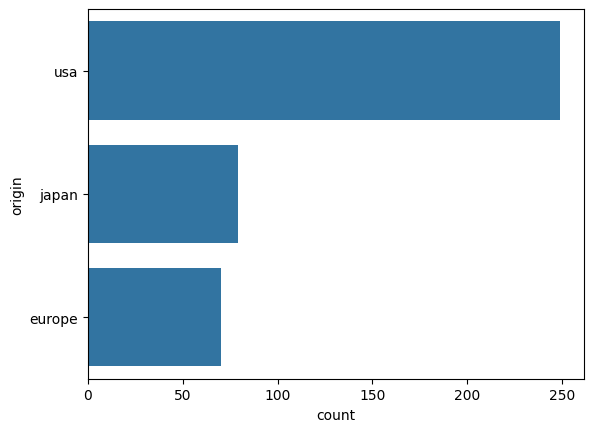

In [35]:
sns.countplot(data=mpg, y='origin')
plt.show()

In [36]:
year_counts = mpg.model_year.value_counts().sort_index()
year_counts

,count
model_year,
70,29
71,28
72,28
73,40
74,27
75,30
76,34
77,28
78,36


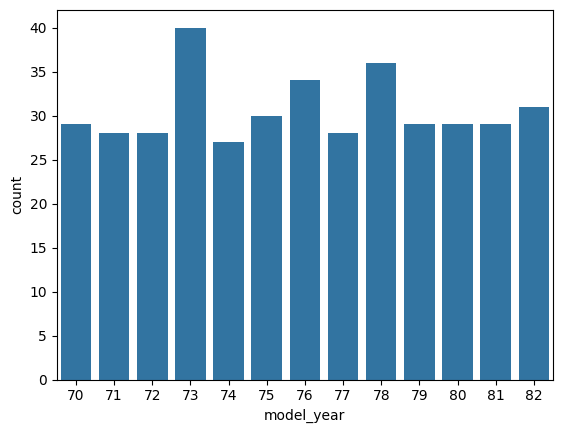

In [37]:
sns.countplot(data=mpg, x='model_year')
plt.show()

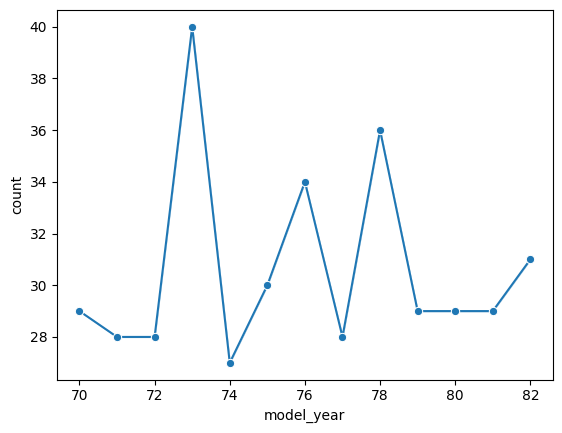

In [38]:
sns.lineplot(data=mpg, x='model_year', y='model_year', estimator='size',
             marker='o')
plt.ylabel('count')
plt.show()

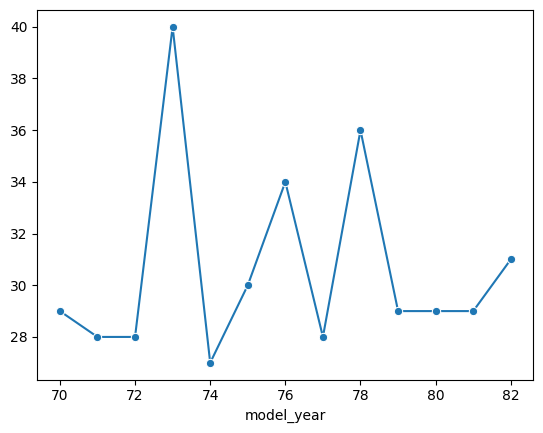

In [39]:
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.show()

In [40]:
# 지역별, 실런더 개수별 빈도수
mpg.groupby(by=['origin', 'cylinders'], observed=True).mpg.count()

origin  cylinders
europe  4             63
        5              3
        6              4
japan   3              4
        4             69
        6              6
usa     4             72
        6             74
        8            103
Name: mpg, dtype: int64

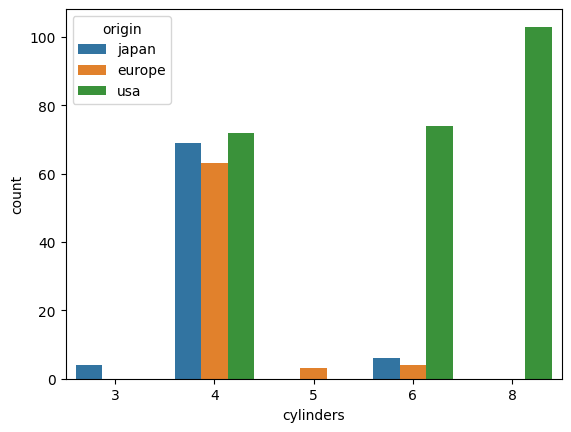

In [41]:
sns.countplot(data=mpg, x='cylinders', hue='origin')
plt.show()

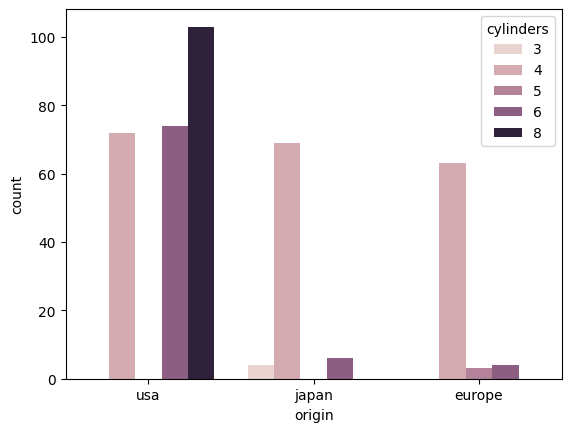

In [42]:
sns.countplot(data=mpg, x='origin', hue='cylinders')
plt.show()

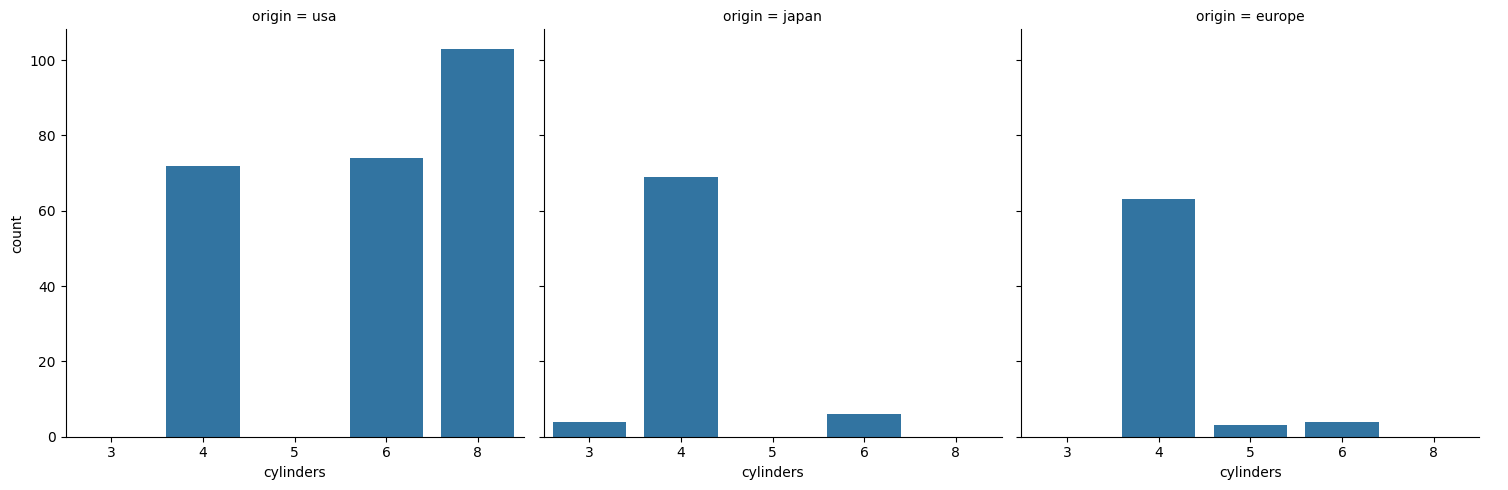

In [43]:
sns.catplot(data=mpg, x='cylinders', col='origin', kind='count')
plt.show()

## Pie chart, Donut chart

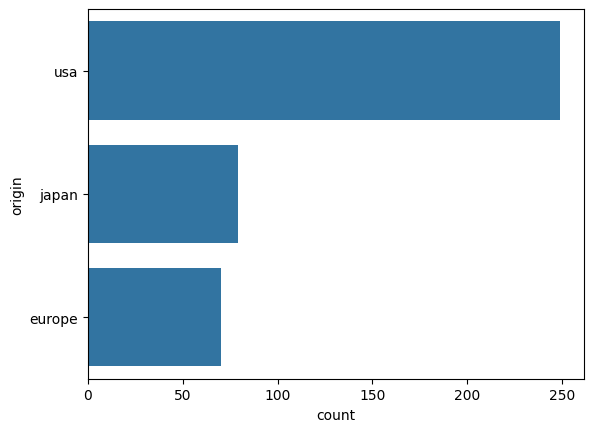

In [44]:
sns.countplot(data=mpg, y='origin')
plt.show()

In [45]:
origin_counts = mpg.origin.value_counts()
origin_counts

,count
origin,
usa,249
japan,79
europe,70


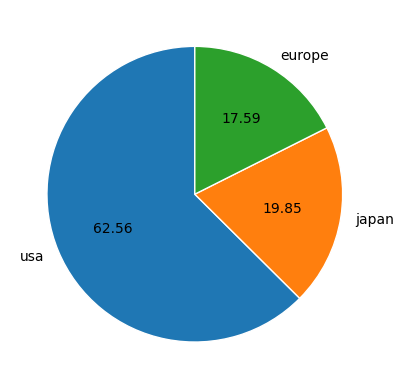

In [46]:
plt.pie(x=origin_counts.values, labels=origin_counts.index,
        startangle=90,
        autopct='%.2f',
        wedgeprops={'edgecolor': 'White', 'linewidth': 1})
plt.show()

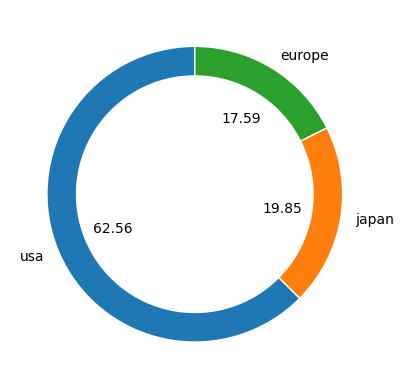

In [47]:
plt.pie(x=origin_counts.values, labels=origin_counts.index,
        startangle=90,
        autopct='%.2f',
        wedgeprops={'edgecolor': 'White', 'linewidth': 1, 'width': 0.2})
plt.show()

## 통계량 막대 그래프

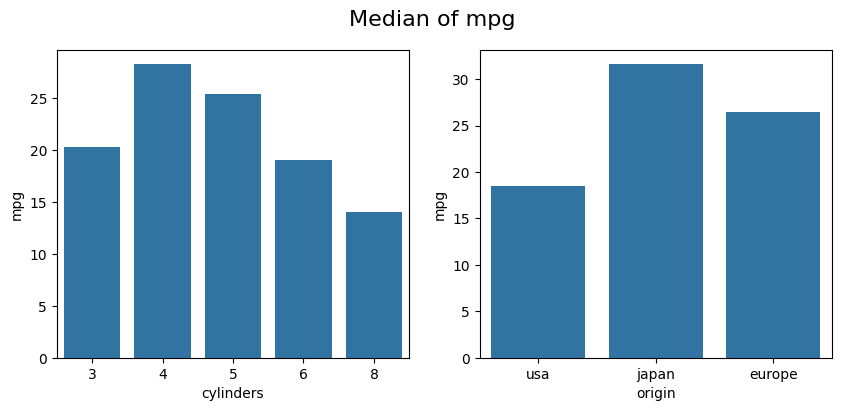

In [57]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

sns.barplot(data=mpg, x='cylinders', y='mpg', estimator='median', ax=axes[0], errorbar=None)
sns.barplot(data=mpg, x='origin', y='mpg', estimator='median', ax=axes[1], errorbar=None)

# axes[0].set_title('Median')  # 각각의 Axes에 차트 제목 설정
fig.suptitle('Median of mpg', fontsize=16)  # Figure 객체 제목 설정

plt.show()

In [58]:
mpg.groupby(by='cylinders').mpg.median()

,mpg
cylinders,
3,20.25
4,28.25
5,25.40
6,19.00
8,14.00


In [59]:
mpg.groupby(by='origin').mpg.median()

,mpg
origin,
europe,26.5
japan,31.6
usa,18.5


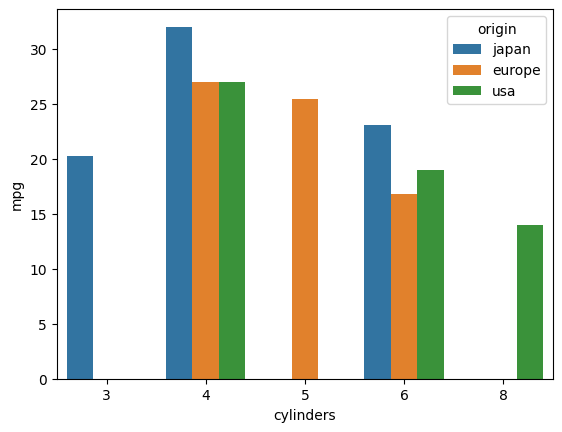

In [60]:
sns.barplot(data=mpg, x='cylinders', y='mpg', hue='origin',
            estimator='median', errorbar=None)
plt.show()

In [61]:
mpg.groupby(by=['cylinders', 'origin'], observed=True).mpg.median()

cylinders  origin
3          japan     20.25
4          europe    27.00
           japan     32.00
           usa       27.00
5          europe    25.40
6          europe    16.75
           japan     23.10
           usa       19.00
8          usa       14.00
Name: mpg, dtype: float64

## Box plot

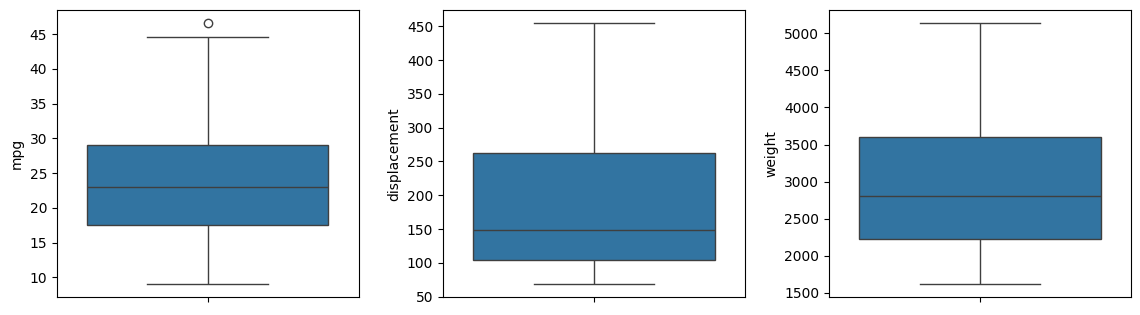

In [73]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
fig.tight_layout(pad=3.0)

vars = ['mpg', 'displacement', 'weight']
for i, v in enumerate(vars):
    sns.boxplot(data=mpg, y=v, ax=axes[i])

plt.show()